Merged daily series (head):
            btc_return  news_sentiment  reddit_sentiment
date                                                    
2024-04-01   -0.023136         -0.0125            0.1185
2024-04-02   -0.061980          0.0786            0.1101
2024-04-03    0.007598          0.0325            0.0814
2024-04-04    0.037557          0.0231            0.1233
2024-04-05   -0.009789         -0.0554            0.1113

Merged daily series (tail):
            btc_return  news_sentiment  reddit_sentiment
date                                                    
2024-12-27   -0.015704          0.1111            0.1047
2024-12-28    0.010559          0.1000            0.0808
2024-12-29   -0.016524          0.0298            0.1216
2024-12-30   -0.010145         -0.0507            0.1069
2024-12-31    0.008413          0.1061            0.1133

Summary statistics:
       btc_return  news_sentiment  reddit_sentiment
count  271.000000      271.000000        271.000000
mean     0.000877   

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Lag 10 ssr F-test p-value: 8.1822e-02
  => Fail to reject H0: no Granger causality at this lag.

Granger causality: btc_return  -->  reddit_sentiment
Null hypothesis: X does NOT Granger cause Y

--- Testing up to 1 lag(s) ---
Lag 1 ssr F-test p-value: 6.0222e-01
  => Fail to reject H0: no Granger causality at this lag.

--- Testing up to 3 lag(s) ---
Lag 3 ssr F-test p-value: 9.6326e-01
  => Fail to reject H0: no Granger causality at this lag.

--- Testing up to 5 lag(s) ---
Lag 5 ssr F-test p-value: 9.9131e-01
  => Fail to reject H0: no Granger causality at this lag.

--- Testing up to 7 lag(s) ---
Lag 7 ssr F-test p-value: 9.9558e-01
  => Fail to reject H0: no Granger causality at this lag.

--- Testing up to 10 lag(s) ---
Lag 10 ssr F-test p-value: 7.5659e-01
  => Fail to reject H0: no Granger causality at this lag.

VAR lag order selection (Google News):
 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
---------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


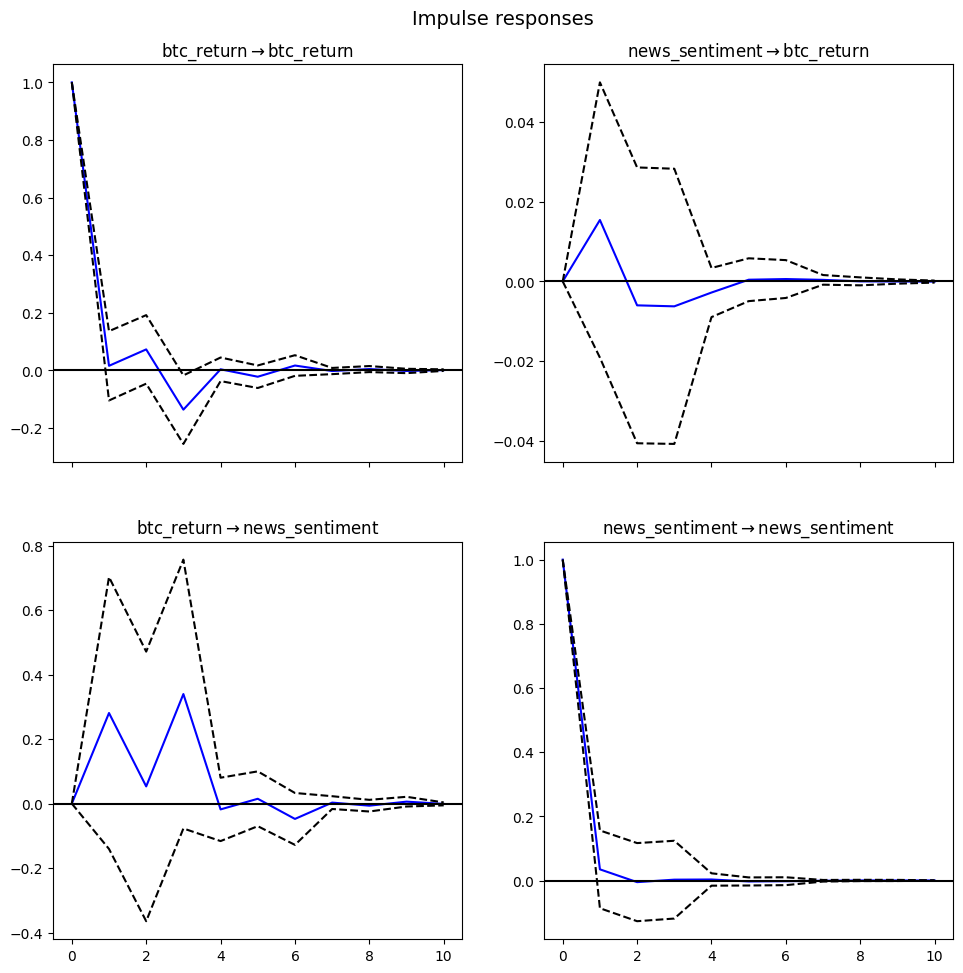


Impulse responses: Reddit shock -> BTC returns


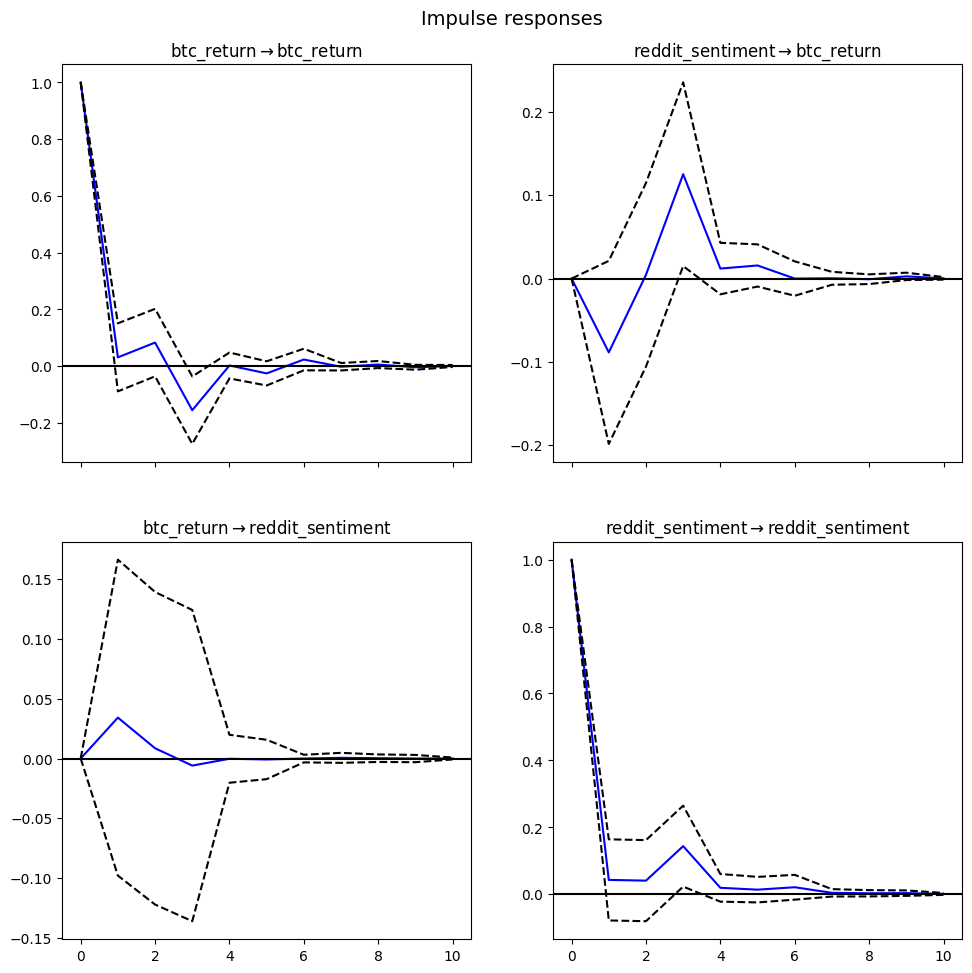

In [13]:
import sys
import numpy as np
import pandas as pd

from statsmodels.tsa.stattools import grangercausalitytests, adfuller
from statsmodels.tsa.api import VAR

# -------------------------------------------------------------------
# 0. Path Setup
# -------------------------------------------------------------------
BASE_DIR = "/content/drive/MyDrive/IST332/FINAL_PROJECT/FINAL_AFTER_FEEDBACK/"
sys.path.append(BASE_DIR)

# -------------------------------------------------------------------
# 1. Load Daily Time Series (Prices + News Sentiment + Reddit Sentiment)
# -------------------------------------------------------------------

# 1a) Google News daily sentiment
news_file = BASE_DIR + "news_sentiment_daily.parquet.gzip"
df_news = pd.read_parquet(news_file)
df_news = df_news.reset_index() # Added: Reset index to make 'date' a column

# Standardize column names if needed
if "news_sentiment" not in df_news.columns:
    if "textblob_mean" in df_news.columns:
        df_news = df_news.rename(columns={"textblob_mean": "news_sentiment"})
    elif "vader_mean" in df_news.columns:
        df_news = df_news.rename(columns={"vader_mean": "news_sentiment"})
    elif "news_polarity_mean" in df_news.columns:
        df_news = df_news.rename(columns={"news_polarity_mean": "news_sentiment"})
    elif "news_sentiment_mean" in df_news.columns:
        df_news = df_news.rename(columns={"news_sentiment_mean": "news_sentiment"})
    else:
        raise KeyError("Could not find a suitable 'news_sentiment' column. Expected 'news_sentiment', 'textblob_mean', 'vader_mean', 'news_polarity_mean', or 'news_sentiment_mean'.")

df_news["date"] = pd.to_datetime(df_news["date"])
df_news = df_news[["date", "news_sentiment"]]

# 1b) Reddit daily sentiment
reddit_file = BASE_DIR + "reddit_sentiment_daily.parquet.gzip"
df_reddit = pd.read_parquet(reddit_file)
df_reddit = df_reddit.reset_index() # Added: Reset index to make 'date' a column

if "reddit_sentiment" not in df_reddit.columns:
    if "textblob_mean" in df_reddit.columns:
        df_reddit = df_reddit.rename(columns={"textblob_mean": "reddit_sentiment"})
    elif "vader_mean" in df_reddit.columns:
        df_reddit = df_reddit.rename(columns={"vader_mean": "reddit_sentiment"})
    elif "reddit_polarity_mean" in df_reddit.columns:
        df_reddit = df_reddit.rename(columns={"reddit_polarity_mean": "reddit_sentiment"})
    elif "reddit_sentiment_mean" in df_reddit.columns:
        df_reddit = df_reddit.rename(columns={"reddit_sentiment_mean": "reddit_sentiment"})
    else:
        raise KeyError("Could not find a suitable 'reddit_sentiment' column. Expected 'reddit_sentiment', 'textblob_mean', 'vader_mean', 'reddit_polarity_mean', or 'reddit_sentiment_mean'.")

df_reddit["date"] = pd.to_datetime(df_reddit["date"])
df_reddit = df_reddit[["date", "reddit_sentiment"]]

# 1c) BTC daily OHLC and returns
price_file = BASE_DIR + "binance_daily_prices.parquet.gzip"
df_price = pd.read_parquet(price_file)
df_price = df_price.reset_index() # Added: Reset index to make 'date' a column

if "close" not in df_price.columns:
    df_price = df_price.rename(
        columns={
            "Close": "close",
            "btc_close": "close",
        }
    )

df_price["date"] = pd.to_datetime(df_price["date"])
df_price = df_price[["date", "close"]].sort_values("date")

# log returns
df_price["btc_return"] = np.log(df_price["close"]).diff()
df_price = df_price.dropna(subset=["btc_return"])

# Merge all three sources
df_daily = (
    df_price.merge(df_news, on="date", how="inner")
            .merge(df_reddit, on="date", how="inner")
)

df_daily = df_daily.sort_values("date").set_index("date")

df_gc = df_daily[["btc_return", "news_sentiment", "reddit_sentiment"]].dropna()

print("Merged daily series (head):")
print(df_gc.head())
print("\nMerged daily series (tail):")
print(df_gc.tail())
print("\nSummary statistics:")
print(df_gc.describe())

# -------------------------------------------------------------------
# 2. Stationarity Checks (ADF Tests)
# -------------------------------------------------------------------
def adf_test(series, name=""):
    series = series.dropna()
    result = adfuller(series, autolag="AIC")
    print(f"\nADF test for {name}")
    print(f"  ADF statistic: {result[0]:.4f}")
    print(f"  p-value      : {result[1]:.4f}")
    print("  => p < 0.05 suggests stationarity")

adf_test(df_gc["btc_return"], "btc_return")
adf_test(df_gc["news_sentiment"], "news_sentiment")
adf_test(df_gc["reddit_sentiment"], "reddit_sentiment")

# If you decide to difference, uncomment this block and set data_gc = df_gc_diff.
# For most returns + daily sentiment, df_gc is usually good enough.

# df_gc_diff = df_gc.copy()
# df_gc_diff["btc_return"] = df_gc_diff["btc_return"].diff()
# df_gc_diff["news_sentiment"] = df_gc_diff["news_sentiment"].diff()
# df_gc_diff["reddit_sentiment"] = df_gc_diff["reddit_sentiment"].diff()
# df_gc_diff = df_gc_diff.dropna()
# data_gc = df_gc_diff

data_gc = df_gc.dropna()

# -------------------------------------------------------------------
# 3. Granger Causality Tests (4 directions, lags 1,3,5,7,10)
# -------------------------------------------------------------------
def run_granger_tests(data, y_col, x_col, max_lags_list):
    """
    data   : DataFrame with at least [y_col, x_col]
    y_col  : dependent variable (Y)
    x_col  : predictor (X)
    max_lags_list : list of lags (e.g., [1,3,5,7,10])
    """
    print("\n======================================================")
    print(f"Granger causality: {x_col}  -->  {y_col}")
    print("Null hypothesis: X does NOT Granger cause Y")
    print("======================================================")

    test_data = data[[y_col, x_col]].dropna()

    for lag in max_lags_list:
        print(f"\n--- Testing up to {lag} lag(s) ---")
        # statsmodels expects [Y, X] in that order
        result = grangercausalitytests(test_data, maxlag=lag, verbose=False)

        # For maxlag = lag, inspect the F-test at that lag
        f_test = result[lag][0]["ssr_ftest"]  # (F statistic, p-value, df_denom, df_num)
        f_pval = f_test[1]

        print(f"Lag {lag} ssr F-test p-value: {f_pval:.4e}")
        if f_pval < 0.01:
            print("  => Reject H0 at 1%: X Granger-causes Y at this lag.")
        elif f_pval < 0.05:
            print("  => Reject H0 at 5%: X Granger-causes Y at this lag.")
        else:
            print("  => Fail to reject H0: no Granger causality at this lag.")

lags_to_test = [1, 3, 5, 7, 10]

# (a) Google News daily sentiment -> BTC returns
run_granger_tests(
    data=data_gc,
    y_col="btc_return",
    x_col="news_sentiment",
    max_lags_list=lags_to_test,
)

# (b) BTC returns -> Google News daily sentiment
run_granger_tests(
    data=data_gc,
    y_col="news_sentiment",
    x_col="btc_return",
    max_lags_list=lags_to_test,
)

# (c) Reddit daily sentiment -> BTC returns
run_granger_tests(
    data=data_gc,
    y_col="btc_return",
    x_col="reddit_sentiment",
    max_lags_list=lags_to_test,
)

# (d) BTC returns -> Reddit daily sentiment
run_granger_tests(
    data=data_gc,
    y_col="reddit_sentiment",
    x_col="btc_return",
    max_lags_list=lags_to_test,
)

# -------------------------------------------------------------------
# 4. VAR Models for Bidirectional Dynamics
# -------------------------------------------------------------------

# 4a) VAR with BTC returns and Google News sentiment
df_var_news = data_gc[["btc_return", "news_sentiment"]].dropna()
model_news = VAR(df_var_news)

print("\nVAR lag order selection (Google News):")
lag_order_results_news = model_news.select_order(maxlags=10)
print(lag_order_results_news.summary())

# Choose lag based on AIC (fallback to 3 if None, or a minimum of 1 if AIC suggests 0)
selected_lag_news = lag_order_results_news.aic
if selected_lag_news == 0:
    lag_news = 3  # Set a minimum lag of 3 for IRF if AIC suggests 0
else:
    lag_news = int(selected_lag_news) if selected_lag_news is not None else 3
print(f"\nSelected VAR lag for Google News (AIC-based or default): {lag_news}")

var_news = model_news.fit(lag_news)
print("\nVAR summary (btc_return, news_sentiment):")
print(var_news.summary())

# 4b) VAR with BTC returns and Reddit sentiment
df_var_reddit = data_gc[["btc_return", "reddit_sentiment"]].dropna()
model_reddit = VAR(df_var_reddit)

print("\nVAR lag order selection (Reddit):")
lag_order_results_reddit = model_reddit.select_order(maxlags=10)
print(lag_order_results_reddit.summary())

selected_lag_reddit = lag_order_results_reddit.aic
if selected_lag_reddit == 0:
    lag_reddit = 3 # Set a minimum lag of 3 for IRF if AIC suggests 0
else:
    lag_reddit = int(selected_lag_reddit) if selected_lag_reddit is not None else 3
print(f"\nSelected VAR lag for Reddit (AIC-based or default): {lag_reddit}")

var_reddit = model_reddit.fit(lag_reddit)
print("\nVAR summary (btc_return, reddit_sentiment):")
print(var_reddit.summary())

# -------------------------------------------------------------------
# 5. Impulse Response Functions (IRFs)
# -------------------------------------------------------------------
#

#
import matplotlib.pyplot as plt
#
print("\nImpulse responses: Google News shock -> BTC returns")
irf_news = var_news.irf(10)  # 10-day horizon
irf_news.plot(orth=False)
plt.show()
#
print("\nImpulse responses: Reddit shock -> BTC returns")
irf_reddit = var_reddit.irf(10)
irf_reddit.plot(orth=False)
plt.show()